# Collect MI Results from Disk & Plot MI Scaling

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from itertools import product
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')

ALGOS = ['Geneformer', 'PCA', 'RandomProjection', 'SCVI', 'State']

# Include all 4 LMI seeds — some algorithms (notably State on
# merfish/larry/shendure) only emit 1404/2303 and never 42, so a
# seeds=[42] filter silently drops those runs entirely. Downstream
# aggregation averages over whichever seeds are present.
SEEDS = [42, 1404, 2303, 2701]

EXPECTED = {
    'PBMC': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422, 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0],
        'signals': ['protein_counts'],
        'seeds': SEEDS,
    },
    'larry': {
        'sizes': [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000],
        'qualities': [0.003876, 0.0071835, 0.0133136, 0.0246748, 0.0457311, 0.0847557, 0.1570821, 0.2911284, 0.5395631, 1.0],
        'signals': ['clone'],
        'seeds': SEEDS,
    },
    'merfish': {
        'sizes': [100, 203, 414, 843, 1716, 3494, 7113, 14480, 29475, 60000],
        'qualities': [0.027248, 0.0406617, 0.0606789, 0.0905502, 0.1351267, 0.2016475, 0.3009156, 0.4490518, 0.6701133, 1.0],
        'signals': ['ng_idx'],
        'seeds': SEEDS,
    },
    'shendure': {
        'sizes': [100, 359, 1291, 4641, 16681, 59948, 215443, 774263, 2782559, 10000000],
        'qualities': [0.004, 0.0073875, 0.0136438, 0.0251984, 0.0465384, 0.0859506, 0.1587401, 0.2931733, 0.5414548, 1.0],
        'signals': ['author_day'],
        'seeds': SEEDS,
    },
}

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _read_mi(path):
    try:
        with open(path) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

# Build expected paths for ALL algorithms (including State)
expected_rows = []
for ds, cfg in EXPECTED.items():
    for sz, q, algo, sig, sd in product(cfg['sizes'], cfg['qualities'], ALGOS, cfg['signals'], cfg['seeds']):
        suffix = '_geneformer' if algo == 'Geneformer' else ''
        stem = f'Y_{sig}_{q}{suffix}'
        mi_path = DATA_ROOT / ds / str(sz) / str(q) / 'results' / algo / 'model' / 'MI' / str(sd) / stem / 'lmi_mutual_information.txt'
        expected_rows.append({
            'dataset': ds, 'size': sz, 'quality': q, 'algorithm': algo,
            'signal': sig, 'seed': sd, 'path': str(mi_path),
        })

df_expected = pd.DataFrame(expected_rows)
print(f'Total expected: {len(df_expected)}')

# Check existence in parallel
with ThreadPoolExecutor(max_workers=128) as pool:
    df_expected['exists'] = list(tqdm(pool.map(os.path.exists, df_expected['path']),
                                      total=len(df_expected), desc='Scanning'))

# Read MI values for found files
df_found = df_expected[df_expected['exists']].copy()
print(f'Found: {len(df_found)}, Missing: {len(df_expected) - len(df_found)}')

with ThreadPoolExecutor(max_workers=128) as pool:
    df_found['mi_value'] = list(tqdm(pool.map(_read_mi, df_found['path']),
                                     total=len(df_found), desc='Reading MI'))

# Final dataframe
out_cols = ['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed', 'mi_value']
df_results = df_found[out_cols].sort_values(out_cols[:-1]).reset_index(drop=True)
print(f'Collected {len(df_results)} MI values (NaN: {df_results["mi_value"].isna().sum()})')

Total expected: 8000


Scanning:   0%|          | 0/8000 [00:00<?, ?it/s]

Scanning: 100%|██████████| 8000/8000 [00:00<00:00, 416204.81it/s]

Found: 4979, Missing: 3021


Reading MI:   0%|          | 0/4979 [00:00<?, ?it/s]

Reading MI:  58%|█████▊    | 2900/4979 [00:00<00:00, 26432.30it/s]

Reading MI: 100%|██████████| 4979/4979 [00:00<00:00, 17091.54it/s]

Collected 4979 MI values (NaN: 0)


In [3]:
# Completeness table: found / expected / missing per dataset × algorithm
pivot = df_expected.groupby(['dataset', 'algorithm'])['exists'].agg(['sum', 'count'])
pivot.columns = ['found', 'expected']
pivot['missing'] = pivot['expected'] - pivot['found']
pivot = pivot.astype(int)

pivot_wide = pivot.unstack('algorithm', fill_value=0).sort_index()
display(pivot_wide)

found                                    expected       \
algorithm Geneformer  PCA RandomProjection SCVI State Geneformer  PCA   
dataset                                                                 
PBMC             396  400              400  400    51        400  400   
larry            300  300              300  300     0        400  400   
merfish          396  400              400  399   137        400  400   
shendure         100  100              100  100     0        400  400   

                                         missing                             \
algorithm RandomProjection SCVI State Geneformer  PCA RandomProjection SCVI   
dataset                                                                       
PBMC                   400  400   400          4    0                0    0   
larry                  400  400   400        100  100              100  100   
merfish                400  400   400          4    0                0    1   
shendure               400  400   400        300  300              300  300   

                 
algorithm State  
dataset          
PBMC        349  
larry       400  
merfish     263  
shendure    400

In [4]:
# Detailed State completeness: rows=size, cols=quality, values=seeds found (0 or 1)
# One table per dataset
df_state_exp = df_expected[df_expected['algorithm'] == 'State'].copy()

for ds in EXPECTED:
    sub = df_state_exp[df_state_exp['dataset'] == ds]
    grid = sub.groupby(['size', 'quality'])['exists'].sum().astype(int).unstack('quality', fill_value=0)
    grid.columns = [f'{q:.4g}' for q in grid.columns]
    grid.index.name = 'size'
    total_found = grid.values.sum()
    total_expected = len(sub)
    print(f'\n{ds}  —  State completeness ({total_found}/{total_expected})')
    display(grid)


PBMC  —  State completeness (51/400)


,0.001235,0.002598,0.005468,0.01151,0.02422,0.05097,0.1073,0.2258,0.4752,1
size,,,,,,,,,,
100,0,1,1,0,1,1,0,1,0,1
215,1,1,0,0,1,1,0,1,1,0
464,0,0,0,0,1,1,1,1,0,0
1000,1,1,1,0,0,0,0,0,0,1
2154,0,0,1,1,1,1,1,0,0,0
4641,0,1,0,0,1,1,0,1,1,0
10000,0,1,0,0,0,1,0,0,0,0
21544,1,0,0,1,1,1,1,1,1,0
46415,1,0,0,0,1,0,1,1,0,1



larry  —  State completeness (0/400)


,0.003876,0.007183,0.01331,0.02467,0.04573,0.08476,0.1571,0.2911,0.5396,1
size,,,,,,,,,,
100,0,0,0,0,0,0,0,0,0,0
215,0,0,0,0,0,0,0,0,0,0
464,0,0,0,0,0,0,0,0,0,0
1000,0,0,0,0,0,0,0,0,0,0
2154,0,0,0,0,0,0,0,0,0,0
4641,0,0,0,0,0,0,0,0,0,0
10000,0,0,0,0,0,0,0,0,0,0
21544,0,0,0,0,0,0,0,0,0,0
46415,0,0,0,0,0,0,0,0,0,0



merfish  —  State completeness (137/400)


,0.02725,0.04066,0.06068,0.09055,0.1351,0.2016,0.3009,0.4491,0.6701,1
size,,,,,,,,,,
100,1,1,1,1,1,2,2,2,1,2
203,1,2,1,2,1,2,1,1,2,2
414,2,2,1,1,1,2,1,1,1,2
843,2,2,1,1,2,2,2,2,1,2
1716,2,1,1,2,1,2,1,1,1,1
3494,2,1,2,2,1,2,1,1,2,1
7113,1,2,2,1,1,1,1,1,2,1
14480,1,1,1,2,1,1,1,1,1,1
29475,2,1,1,1,1,1,2,2,2,1



shendure  —  State completeness (0/400)


,0.004,0.007387,0.01364,0.0252,0.04654,0.08595,0.1587,0.2932,0.5415,1
size,,,,,,,,,,
100,0,0,0,0,0,0,0,0,0,0
359,0,0,0,0,0,0,0,0,0,0
1291,0,0,0,0,0,0,0,0,0,0
4641,0,0,0,0,0,0,0,0,0,0
16681,0,0,0,0,0,0,0,0,0,0
59948,0,0,0,0,0,0,0,0,0,0
215443,0,0,0,0,0,0,0,0,0,0
774263,0,0,0,0,0,0,0,0,0,0
2782559,0,0,0,0,0,0,0,0,0,0


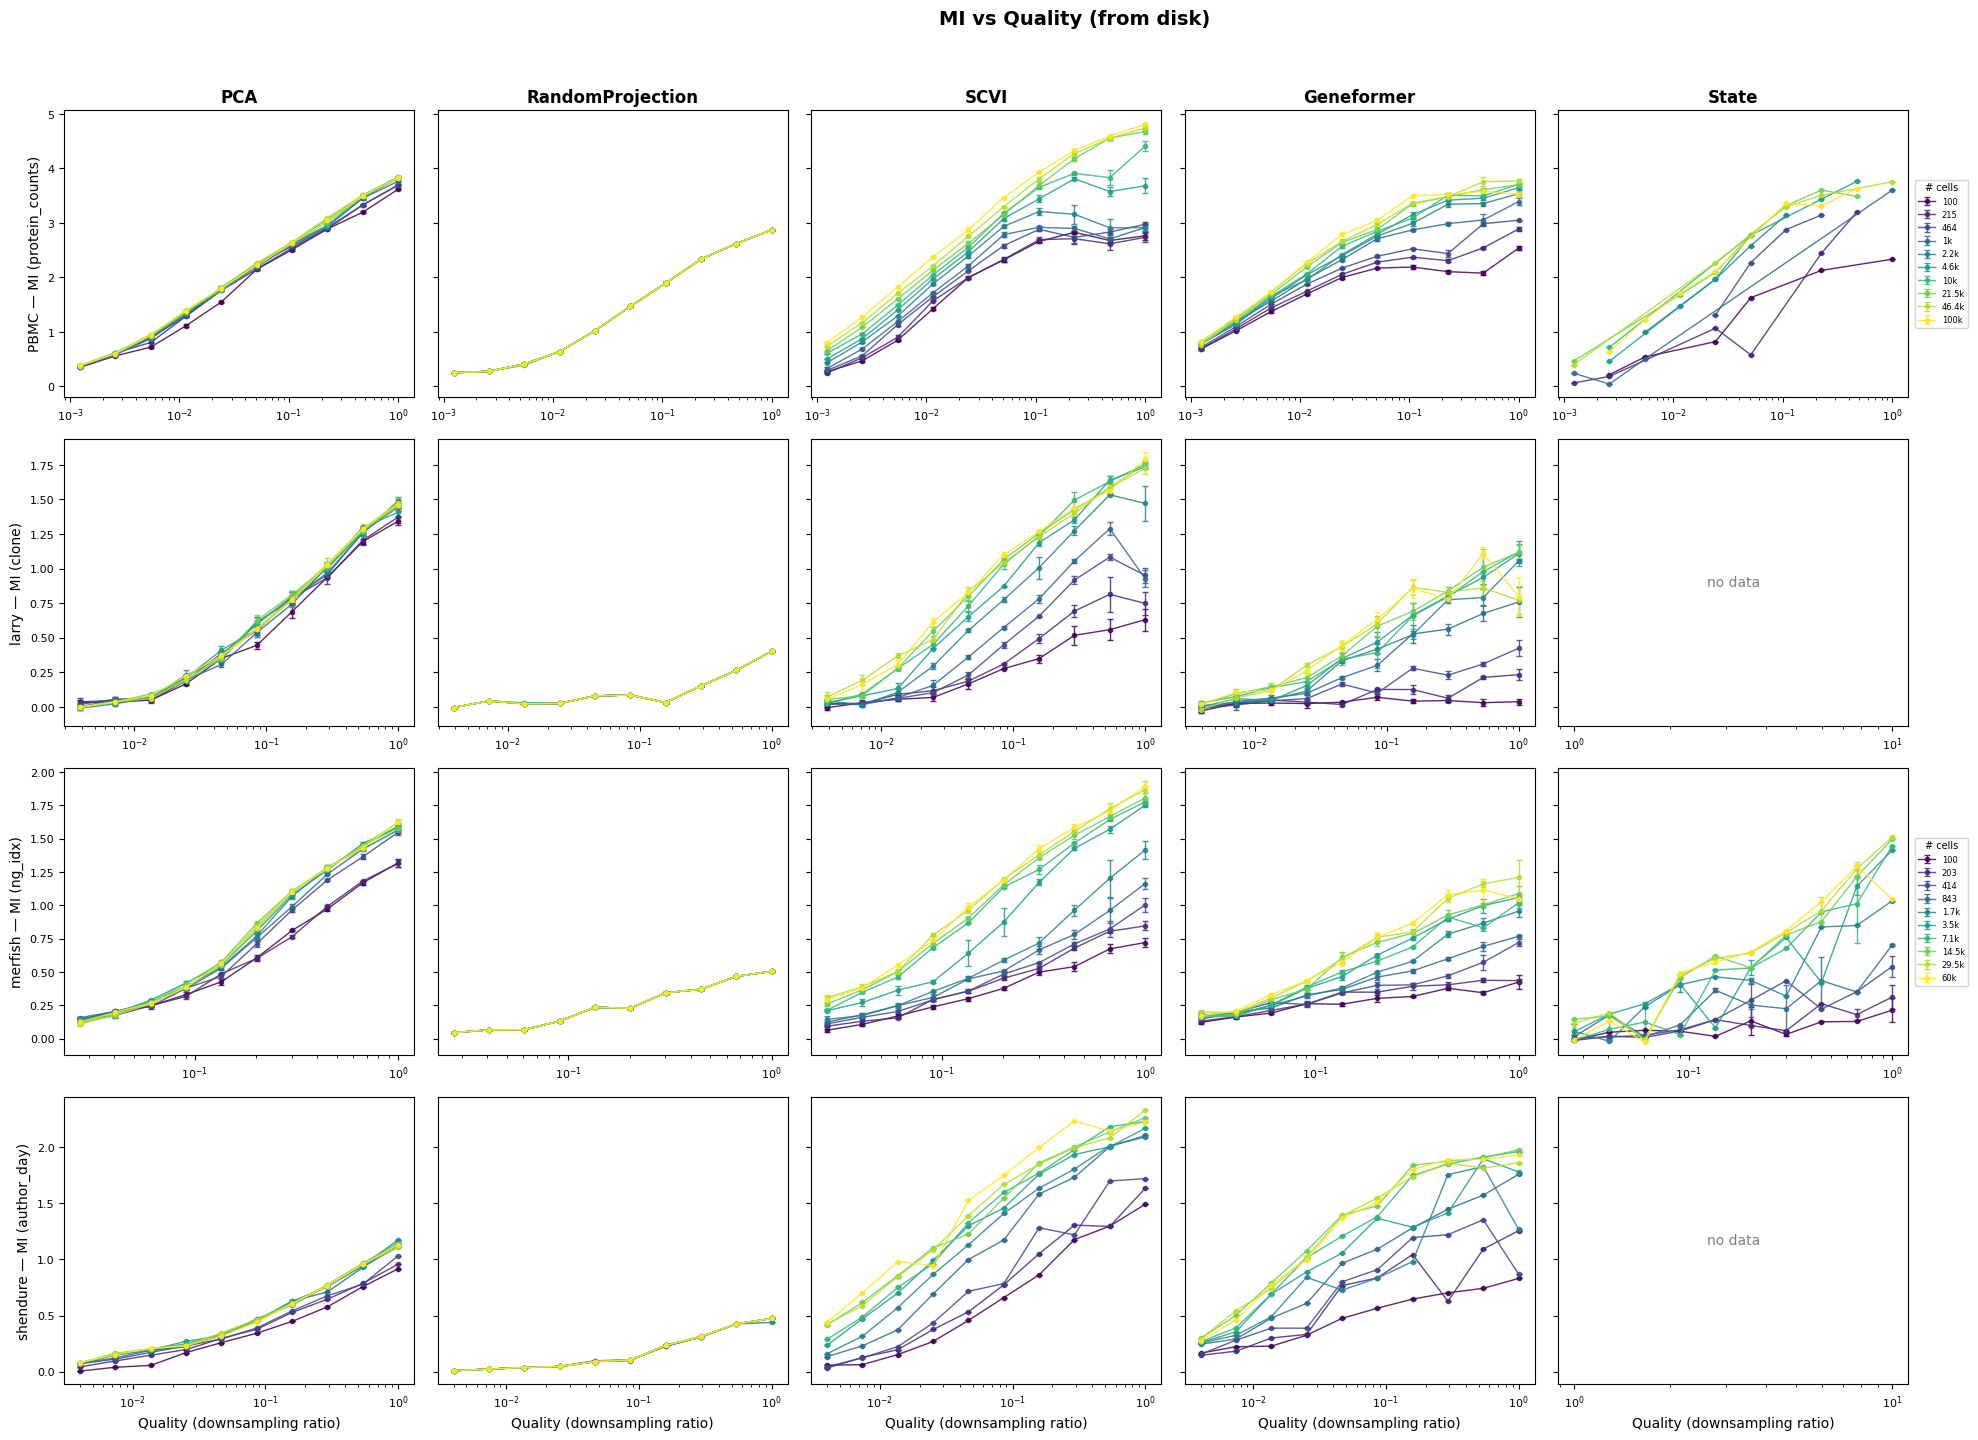

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

ALGO_ORDER = ['PCA', 'RandomProjection', 'SCVI', 'Geneformer', 'State']

def _fmt_size(sz):
    """Human-readable size label: 100, 1k, 10k, 1M, 10M, etc."""
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

def plot_mi_vs_quality(df):
    """Plot MI vs quality: rows=dataset×signal, cols=algorithm, curves=size.
    Per-dataset color norm and legend to the right of each row."""
    all_ds_sig = sorted(set(zip(df['dataset'], df['signal'])))
    algorithms = [a for a in ALGO_ORDER if a in df['algorithm'].unique()]
    n_rows = len(all_ds_sig)
    n_cols = len(algorithms)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 1.6, 3.5 * n_rows + 0.8),
                             squeeze=False, sharex=False)

    # Share y-axis within each row
    for i in range(n_rows):
        for j in range(1, n_cols):
            axes[i, j].sharey(axes[i, 0])

    cmap = plt.cm.viridis

    # Per-dataset size norms
    ds_norms = {}
    for ds, _ in all_ds_sig:
        sizes = sorted(df[df['dataset'] == ds]['size'].unique())
        if sizes:
            ds_norms[ds] = mcolors.LogNorm(vmin=min(sizes), vmax=max(sizes))

    for i, (ds, sig) in enumerate(all_ds_sig):
        norm = ds_norms.get(ds)
        for j, algo in enumerate(algorithms):
            ax = axes[i, j]
            sub = df[(df['dataset'] == ds) & (df['algorithm'] == algo) & (df['signal'] == sig)]

            if sub.empty:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='gray', fontsize=10)
                ax.set_xscale('log')
            else:
                for sz in sorted(sub['size'].unique()):
                    color = cmap(norm(sz))
                    sz_df = sub[sub['size'] == sz]
                    agg = sz_df.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                    agg = agg.sort_values('quality')
                    agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                    ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                                marker='o', markersize=3, linewidth=1, capsize=2,
                                color=color, alpha=0.85, label=_fmt_size(sz))
                ax.set_xscale('log')

            if i == n_rows - 1:
                ax.set_xlabel('Quality (downsampling ratio)', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'{ds} — MI ({sig})', fontsize=10)
            if i == 0:
                ax.set_title(algo, fontsize=12, fontweight='bold')
            ax.tick_params(labelsize=8)
            if j > 0:
                ax.tick_params(labelleft=False)

        # Legend to the right of the last column for this row
        last_ax = axes[i, n_cols - 1]
        handles, labels = last_ax.get_legend_handles_labels()
        if handles:
            last_ax.legend(handles, labels, title='# cells', fontsize=6,
                           title_fontsize=7, loc='center left',
                           bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                           frameon=True, framealpha=0.8)

    fig.suptitle('MI vs Quality (from disk)',
                 fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
    plt.show()
    return fig

fig_quality = plot_mi_vs_quality(df_results)

In [6]:
# ── Fit noise scaling laws ──────────────────────────────────────────────
# For each (dataset, algorithm, signal, size) group, fit:
#   I(u) = I_max - 0.5 * log2( (1 + u/u_bar) / (u/u_bar + 2^(-2*I_max)) )
# where u = quality (downsampling fraction, proportional to UMIs/cell).

from lmfit import Model
import warnings

def info_scaling(u, u_bar, I_max):
    u = np.asarray(u, dtype=float)
    u_bar = np.asarray(u_bar, dtype=float)
    I_max = np.asarray(I_max, dtype=float)
    eps = 1e-12
    u_bar_safe = np.where(u_bar == 0, eps, u_bar)
    r = u / u_bar_safe
    num = 1 + r
    den = r + 2 ** (-2 * I_max)
    den = np.where(den == 0, eps, den)
    ratio = np.clip(num / den, eps, None)
    return I_max - 0.5 * np.log2(ratio)

def fit_one_group(u_values, mi_values):
    """Fit the noise-scaling model to one (dataset, algo, signal, size) slice."""
    model = Model(info_scaling)
    params = model.make_params(u_bar=0.05, I_max=1.0)
    params['u_bar'].min = 1e-12
    params['I_max'].min = 0
    try:
        result = model.fit(mi_values, params, u=u_values)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                y_unc = result.eval_uncertainty(params=result.params, u=u_values, sigma=2)
            except Exception:
                y_unc = np.zeros_like(u_values)
        return {
            'u_bar':     result.params['u_bar'].value,
            'I_max':     result.params['I_max'].value,
            'u_bar_err': result.params['u_bar'].stderr,
            'I_max_err': result.params['I_max'].stderr,
            'avg_unc':   np.mean(np.abs(y_unc)),
            'success':   True,
        }
    except Exception:
        return {k: np.nan for k in ['u_bar', 'I_max', 'u_bar_err', 'I_max_err', 'avg_unc']} | {'success': False}

# --- run fits ---
fit_records = []
groups = df_results.groupby(['dataset', 'algorithm', 'signal', 'size'])
for (ds, algo, sig, sz), grp in tqdm(groups, desc='Fitting noise scaling'):
    if len(grp) < 3:
        continue
    agg = grp.groupby('quality')['mi_value'].mean().reset_index().sort_values('quality')
    res = fit_one_group(agg['quality'].values, agg['mi_value'].values)
    fit_records.append({
        'dataset': ds, 'algorithm': algo, 'signal': sig, 'size': sz, **res,
    })

df_fits = pd.DataFrame(fit_records)
n_ok = df_fits['success'].sum()
print(f'Fitted {n_ok}/{len(df_fits)} groups successfully')
display(df_fits[df_fits['success']].head(10))

Fitting noise scaling:   0%|          | 0/180 [00:00<?, ?it/s]

Fitting noise scaling:   8%|▊         | 15/180 [00:00<00:01, 141.67it/s]

Fitting noise scaling:  17%|█▋        | 30/180 [00:00<00:01, 132.99it/s]

Fitting noise scaling:  24%|██▍       | 44/180 [00:00<00:01, 81.01it/s] 

Fitting noise scaling:  30%|███       | 54/180 [00:00<00:01, 80.71it/s]

...

Fitting noise scaling:  86%|████████▌ | 155/180 [00:01<00:00, 85.09it/s]

Fitting noise scaling:  94%|█████████▍| 169/180 [00:01<00:00, 95.43it/s]

Fitting noise scaling: 100%|██████████| 180/180 [00:01<00:00, 100.03it/s]

Fitted 179/179 groups successfully


,dataset,algorithm,signal,size,u_bar,I_max,u_bar_err,I_max_err,avg_unc,success
0,PBMC,Geneformer,protein_counts,100,0.016296,2.295667,0.003290,0.063985,0.133465,True
1,PBMC,Geneformer,protein_counts,215,0.027654,2.605766,0.005669,0.074431,0.143740,True
2,PBMC,Geneformer,protein_counts,464,0.037640,2.853761,0.008741,0.091248,0.167406,True
3,PBMC,Geneformer,protein_counts,1000,0.057473,3.231384,0.007423,0.055997,0.094773,True
4,PBMC,Geneformer,protein_counts,2154,0.086508,3.518321,0.007697,0.041547,0.064007,True
5,PBMC,Geneformer,protein_counts,4641,0.107090,3.658783,0.009510,0.042927,0.062550,True
6,PBMC,Geneformer,protein_counts,10000,0.104398,3.703316,0.010976,0.050862,0.074741,True
7,PBMC,Geneformer,protein_counts,21544,0.099705,3.758145,0.007035,0.034106,0.050834,True
8,PBMC,Geneformer,protein_counts,46415,0.111933,3.851439,0.010084,0.044373,0.064127,True
9,PBMC,Geneformer,protein_counts,100000,0.080179,3.716904,0.011765,0.069018,0.108911,True


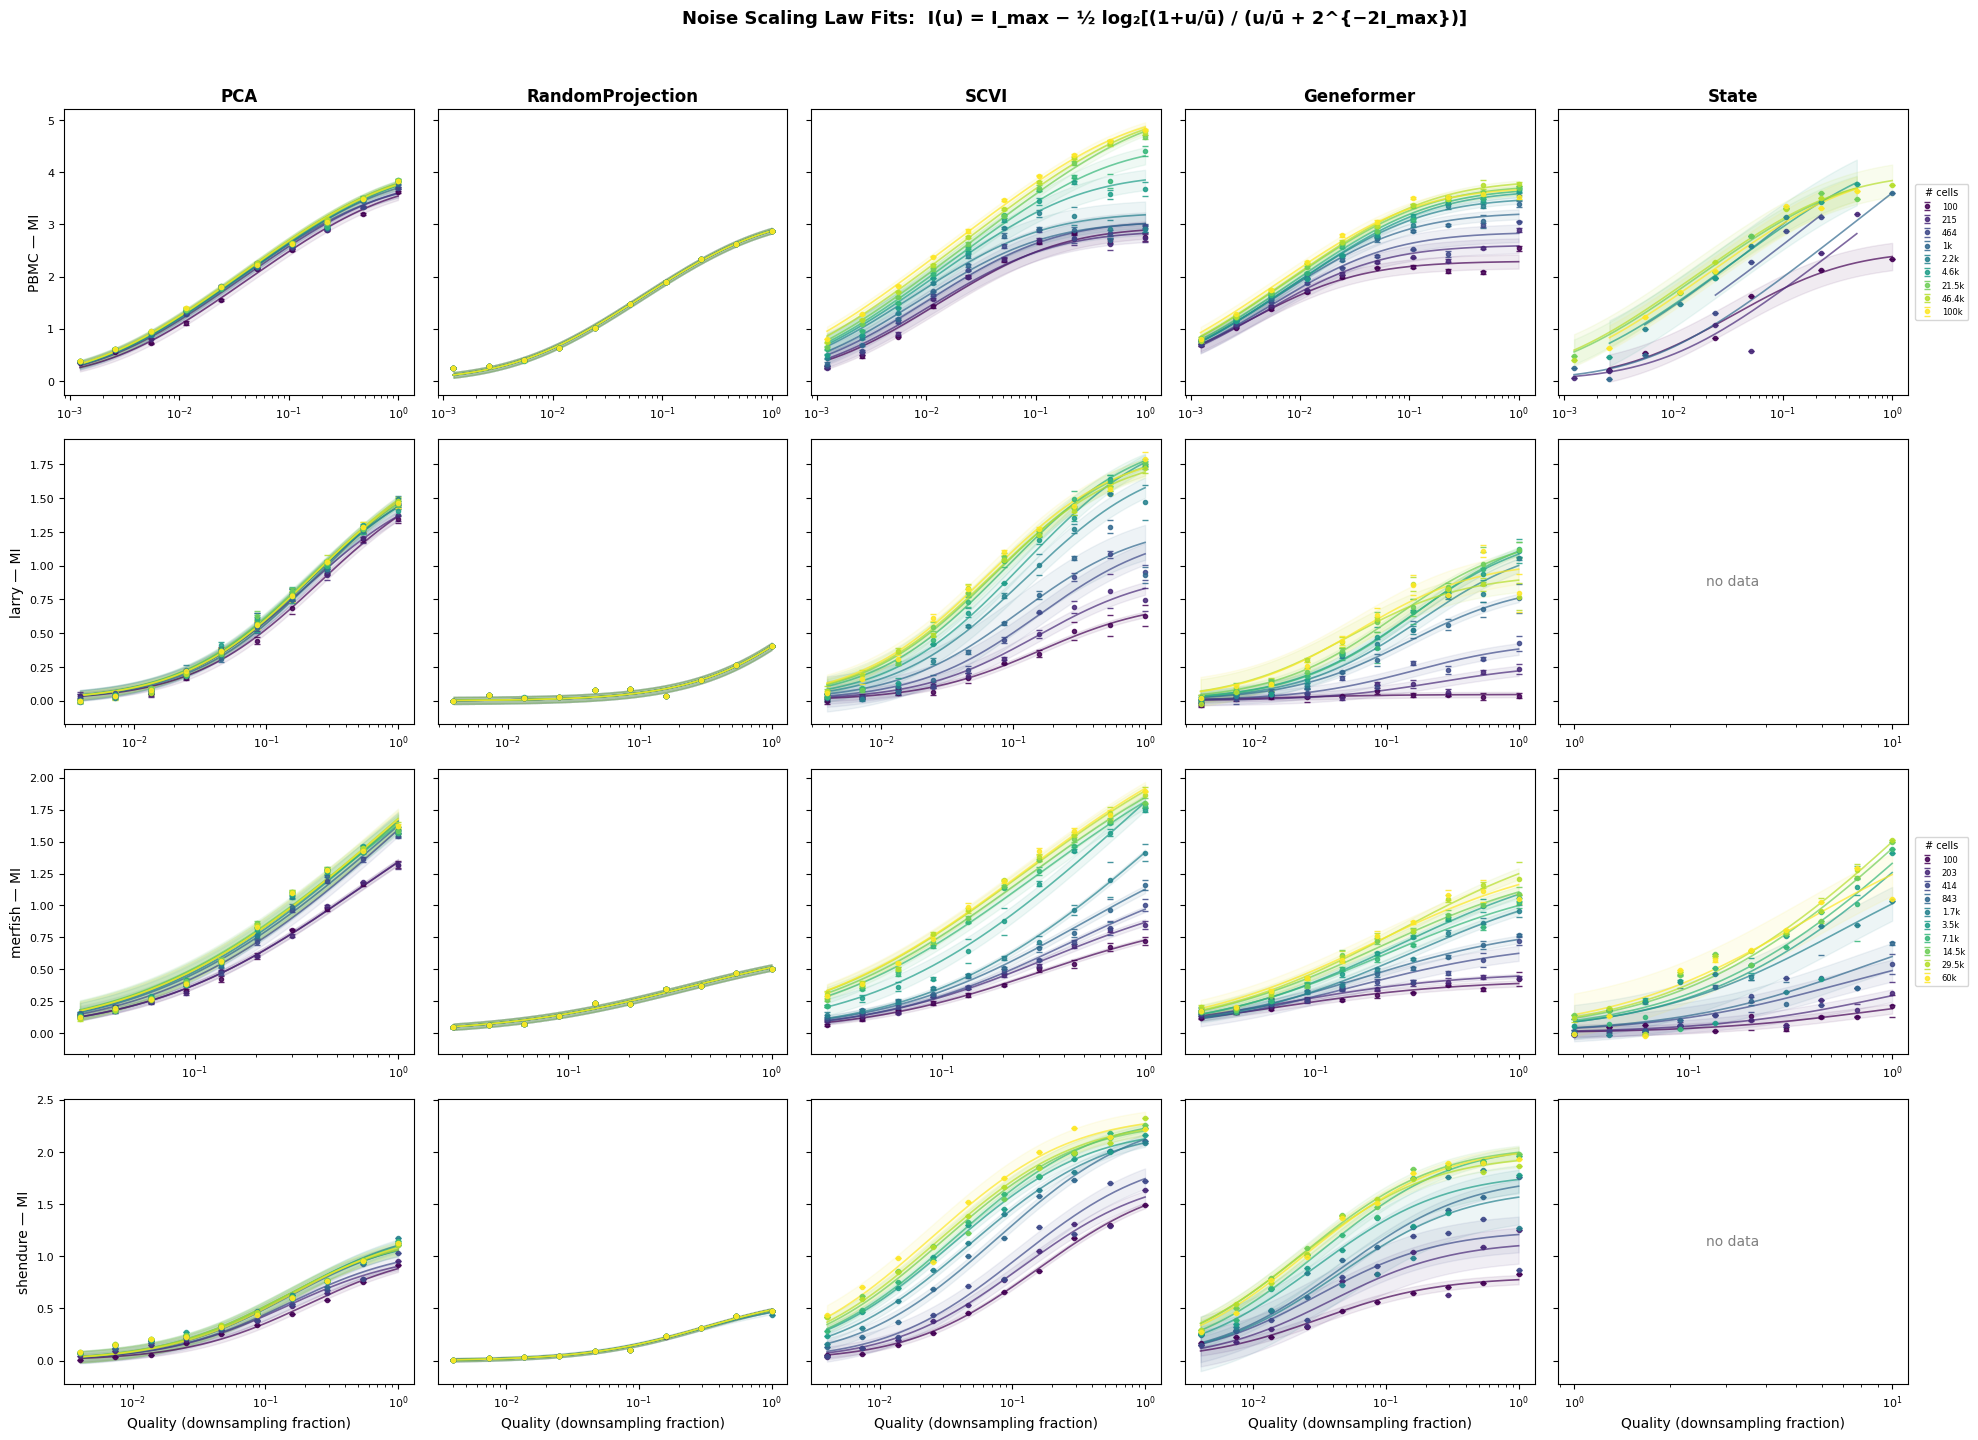

In [7]:
# ── Visualize noise scaling fits ────────────────────────────────────────
# Rows = datasets, Cols = algorithms
# Each subplot shows one fitted curve per size, with data points + uncertainty bands.

import matplotlib.colors as mcolors

df_ok = df_fits[df_fits['success']].copy()

datasets_order = sorted(df_ok['dataset'].unique())
algo_order = [a for a in ALGO_ORDER if a in df_ok['algorithm'].unique()]
n_rows = len(datasets_order)
n_cols = len(algo_order)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols + 1.6, 3.5 * n_rows + 0.8),
                         squeeze=False)

# share y within each row
for i in range(n_rows):
    for j in range(1, n_cols):
        axes[i, j].sharey(axes[i, 0])

cmap = plt.cm.viridis

for i, ds in enumerate(datasets_order):
    # per-dataset size color norm
    sizes_ds = sorted(df_ok[df_ok['dataset'] == ds]['size'].unique())
    if not sizes_ds:
        continue
    norm = mcolors.LogNorm(vmin=min(sizes_ds), vmax=max(sizes_ds))

    for j, algo in enumerate(algo_order):
        ax = axes[i, j]
        sub_fits = df_ok[(df_ok['dataset'] == ds) & (df_ok['algorithm'] == algo)]
        sub_data = df_results[(df_results['dataset'] == ds) & (df_results['algorithm'] == algo)]

        if sub_fits.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)
            ax.set_xscale('log')
        else:
            for _, row in sub_fits.iterrows():
                sz = row['size']
                color = cmap(norm(sz))
                u_bar, I_max = row['u_bar'], row['I_max']

                # plot data points
                pts = sub_data[sub_data['size'] == sz]
                agg = pts.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                agg = agg.sort_values('quality')
                agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
                ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                            marker='o', markersize=3, linewidth=0, capsize=2,
                            color=color, alpha=0.85, label=_fmt_size(sz))

                # plot fitted curve
                q_range = np.logspace(np.log10(agg['quality'].min()),
                                      np.log10(agg['quality'].max()), 200)
                fitted = info_scaling(q_range, u_bar, I_max)
                ax.plot(q_range, fitted, color=color, lw=1.2, alpha=0.7)

                # uncertainty band (constant approximation from avg_unc)
                if not np.isnan(row['avg_unc']) and row['avg_unc'] <= 0.5:
                    ax.fill_between(q_range,
                                    fitted - row['avg_unc'],
                                    fitted + row['avg_unc'],
                                    color=color, alpha=0.08)

            ax.set_xscale ('log')

        if i == n_rows - 1:
            ax.set_xlabel('Quality (downsampling fraction)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'{ds} — MI', fontsize=10)
        if i == 0:
            ax.set_title(algo, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=8)
        if j > 0:
            ax.tick_params(labelleft=False)

    # legend to the right of last column
    last_ax = axes[i, n_cols - 1]
    handles, labels = last_ax.get_legend_handles_labels()
    if handles:
        last_ax.legend(handles, labels, title='# cells', fontsize=6,
                       title_fontsize=7, loc='center left',
                       bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                       frameon=True, framealpha=0.8)

fig.suptitle('Noise Scaling Law Fits:  I(u) = I_max − ½ log₂[(1+u/ū) / (u/ū + 2^{−2I_max})]',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.01, 0.92, 0.96])
plt.show()